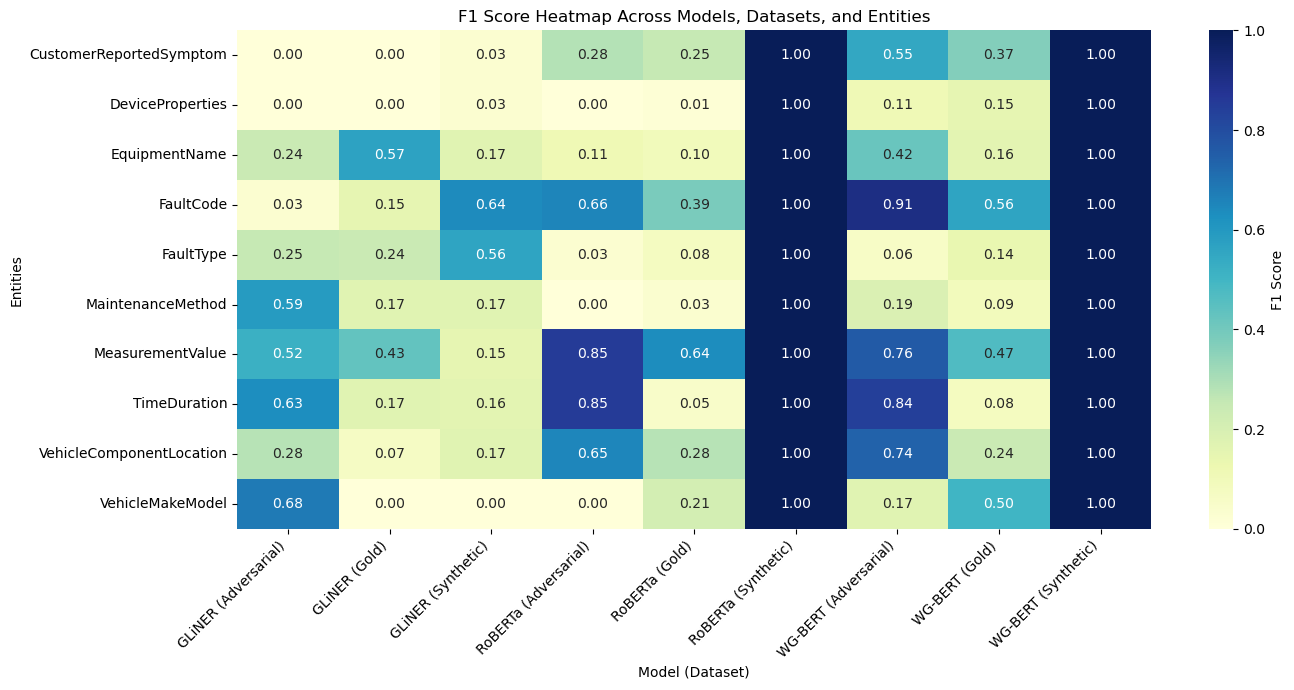

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Define entities
entities = [
    "CustomerReportedSymptom", "DeviceProperties", "EquipmentName", "FaultCode",
    "FaultType", "MaintenanceMethod", "MeasurementValue", "TimeDuration",
    "VehicleComponentLocation", "VehicleMakeModel"
]

# F1 scores for each model and dataset
data = {
    "WG-BERT": {
        "Synthetic": [1.00]*10,
        "Gold": [0.37, 0.15, 0.16, 0.56, 0.14, 0.09, 0.47, 0.08, 0.24, 0.50],
        "Adversarial": [0.55, 0.11, 0.42, 0.91, 0.06, 0.19, 0.76, 0.84, 0.74, 0.17]
    },
    "RoBERTa": {
        "Synthetic": [1.00]*10,
        "Gold": [0.252, 0.012, 0.096, 0.385, 0.076, 0.033, 0.636, 0.053, 0.278, 0.211],
        "Adversarial": [0.284, 0.0, 0.114, 0.655, 0.031, 0.0, 0.854, 0.852, 0.651, 0.0]
    },
    "GLiNER": {
        "Synthetic": [0.03, 0.03, 0.17, 0.64, 0.56, 0.17, 0.15, 0.16, 0.17, 0.0],
        "Gold": [0.00, 0.00, 0.57, 0.15, 0.24, 0.17, 0.43, 0.17, 0.07, 0.00],
        "Adversarial": [0.00, 0.00, 0.24, 0.03, 0.25, 0.59, 0.52, 0.63, 0.28, 0.68]
    }
}

# Prepare a DataFrame for heatmap
rows = []
for model in data:
    for dataset in data[model]:
        for ent, f1 in zip(entities, data[model][dataset]):
            rows.append({"Model": model, "Dataset": dataset, "Entity": ent, "F1": f1})

df = pd.DataFrame(rows)

# Pivot table: rows = Entity, columns = Model-Dataset combination
df['Model-Dataset'] = df['Model'] + " (" + df['Dataset'] + ")"
heatmap_data = df.pivot(index='Entity', columns='Model-Dataset', values='F1')

# Plot heatmap
plt.figure(figsize=(14,7))
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', fmt=".2f", cbar_kws={'label': 'F1 Score'})
plt.title("F1 Score Heatmap Across Models, Datasets, and Entities")
plt.ylabel("Entities")
plt.xlabel("Model (Dataset)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


/var/folders/hx/q1s4c6ws0dn84_dnnjvs7skc0000gp/T/ipykernel_29301/1146133625.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/var/folders/hx/q1s4c6ws0dn84_dnnjvs7skc0000gp/T/ipykernel_29301/1146133625.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/var/folders/hx/q1s4c6ws0dn84_dnnjvs7skc0000gp/T/ipykernel_29301/1146133625.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


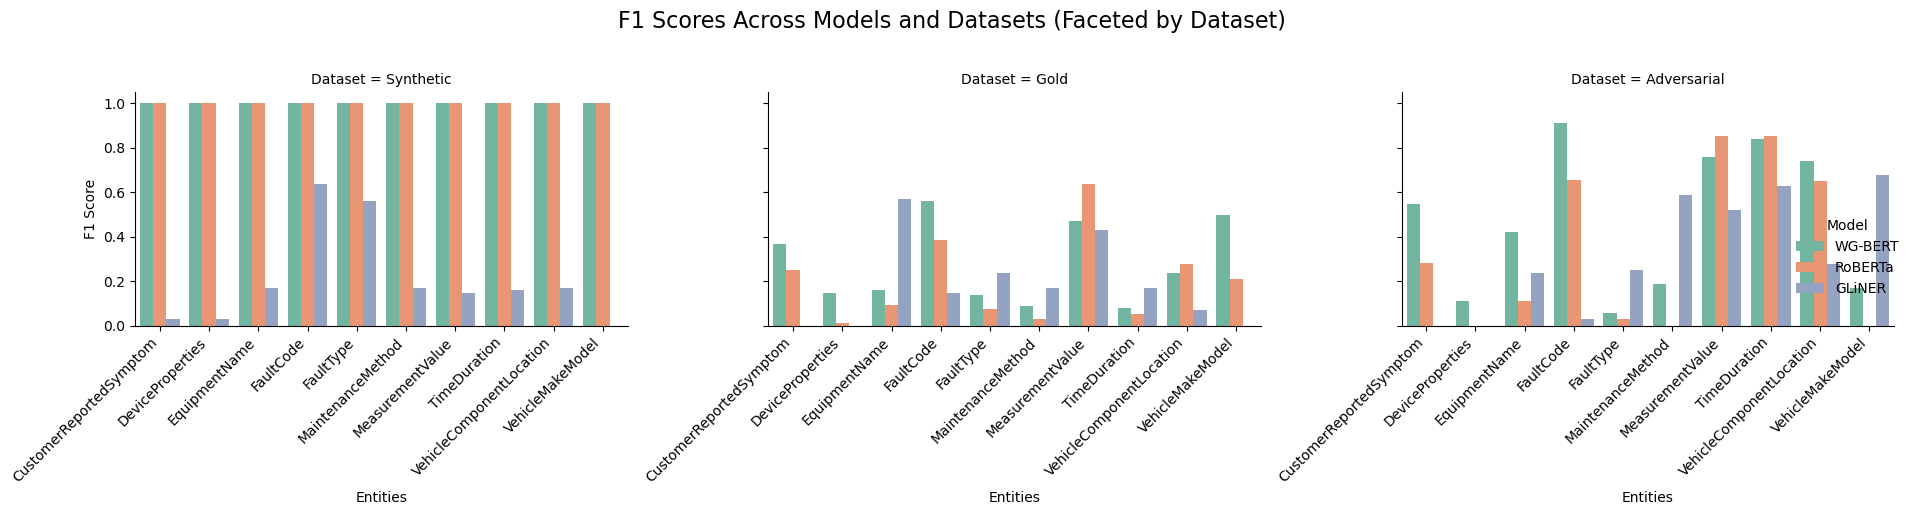

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define entities
entities = [
    "CustomerReportedSymptom", "DeviceProperties", "EquipmentName", "FaultCode",
    "FaultType", "MaintenanceMethod", "MeasurementValue", "TimeDuration",
    "VehicleComponentLocation", "VehicleMakeModel"
]

# F1 scores for each model and dataset
data = {
    "WG-BERT": {
        "Synthetic": [1.00]*10,
        "Gold": [0.37, 0.15, 0.16, 0.56, 0.14, 0.09, 0.47, 0.08, 0.24, 0.50],
        "Adversarial": [0.55, 0.11, 0.42, 0.91, 0.06, 0.19, 0.76, 0.84, 0.74, 0.17]
    },
    "RoBERTa": {
        "Synthetic": [1.00]*10,
        "Gold": [0.252, 0.012, 0.096, 0.385, 0.076, 0.033, 0.636, 0.053, 0.278, 0.211],
        "Adversarial": [0.284, 0.0, 0.114, 0.655, 0.031, 0.0, 0.854, 0.852, 0.651, 0.0]
    },
    "GLiNER": {
        "Synthetic": [0.03, 0.03, 0.17, 0.64, 0.56, 0.17, 0.15, 0.16, 0.17, 0.0],
        "Gold": [0.00, 0.00, 0.57, 0.15, 0.24, 0.17, 0.43, 0.17, 0.07, 0.00],
        "Adversarial": [0.00, 0.00, 0.24, 0.03, 0.25, 0.59, 0.52, 0.63, 0.28, 0.68]
    }
}

# Prepare DataFrame for FacetGrid
rows = []
for model in data:
    for dataset in data[model]:
        for ent, f1 in zip(entities, data[model][dataset]):
            rows.append({"Model": model, "Dataset": dataset, "Entity": ent, "F1": f1})

df = pd.DataFrame(rows)

# Create faceted bar plots: one facet per Dataset
g = sns.FacetGrid(df, col="Dataset", sharey=True, height=5, aspect=1.2)
g.map_dataframe(sns.barplot, x="Entity", y="F1", hue="Model", palette="Set2")
g.add_legend(title="Model")
g.set_axis_labels("Entities", "F1 Score")
for ax in g.axes.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.suptitle("F1 Scores Across Models and Datasets (Faceted by Dataset)", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()


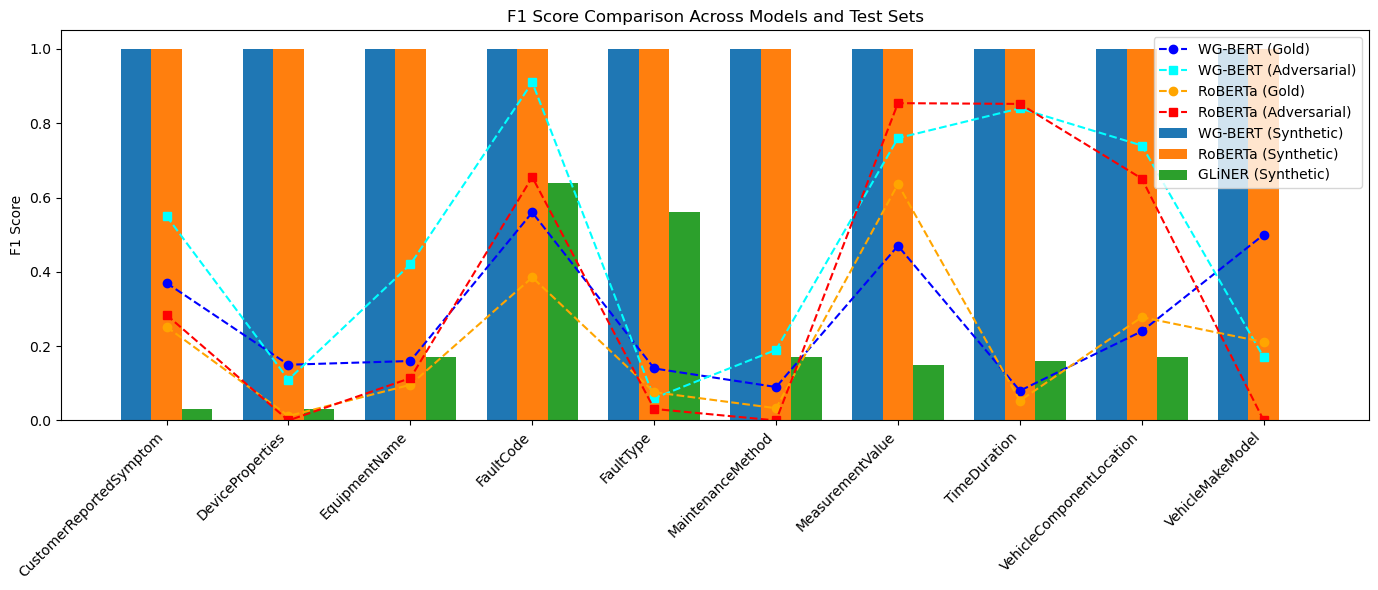

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Define entities
entities = [
    "CustomerReportedSymptom", "DeviceProperties", "EquipmentName", "FaultCode",
    "FaultType", "MaintenanceMethod", "MeasurementValue", "TimeDuration",
    "VehicleComponentLocation", "VehicleMakeModel"
]

# F1 scores for each model and test set
# WG-BERT
wgbert_synthetic = [1.00]*10
wgbert_gold      = [0.37, 0.15, 0.16, 0.56, 0.14, 0.09, 0.47, 0.08, 0.24, 0.50]
wgbert_adversarial = [0.55, 0.11, 0.42, 0.91, 0.06, 0.19, 0.76, 0.84, 0.74, 0.17]

# RoBERTa
roberta_synthetic = [1.00]*10
roberta_gold      = [0.252, 0.012, 0.096, 0.385, 0.076, 0.033, 0.636, 0.053, 0.278, 0.211]
roberta_adversarial = [0.284, 0.0, 0.114, 0.655, 0.031, 0.0, 0.854, 0.852, 0.651, 0.0]

# GLiNER (only synthetic)
gliner_synthetic = [0.03, 0.03, 0.17, 0.64, 0.56, 0.17, 0.15, 0.16, 0.17, 0.0]

# Plotting
x = np.arange(len(entities))
width = 0.25

plt.figure(figsize=(14,6))

# Bars for synthetic
plt.bar(x - width, wgbert_synthetic, width, label='WG-BERT (Synthetic)')
plt.bar(x, roberta_synthetic, width, label='RoBERTa (Synthetic)')
plt.bar(x + width, gliner_synthetic, width, label='GLiNER (Synthetic)')

# Overlay line plots for gold and adversarial for WG-BERT and RoBERTa
plt.plot(x, wgbert_gold, 'o--', color='blue', label='WG-BERT (Gold)')
plt.plot(x, wgbert_adversarial, 's--', color='cyan', label='WG-BERT (Adversarial)')
plt.plot(x, roberta_gold, 'o--', color='orange', label='RoBERTa (Gold)')
plt.plot(x, roberta_adversarial, 's--', color='red', label='RoBERTa (Adversarial)')

plt.xticks(x, entities, rotation=45, ha='right')
plt.ylabel('F1 Score')
plt.title('F1 Score Comparison Across Models and Test Sets')
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()
